# Линейная регрессия


Линейные методы предполагают, что между признаками объекта и целевой переменной существует линейная зависимость, то есть:
$$ \hat{y} = w_1 x_1 + w_2 x_2 + ... + w_k x_k + b,$$
где $\hat{y}$ - целевая переменная (что мы хотим предсказать), $x_i$ - i-ый признак объекта $x$, $w_i$ - вес $i$-го признака, $b$ - bias (смещение, свободный член).

В задаче линейной регрессии $\hat{y}$ - это действительное число.

Часто для упрощения записи вводят дополнительный фиктивный признак $x_0$, который всегда равен 1, тогда bias - вес этого признака. В этом случае формула может быть записана как скалярное произведение:
$$ \hat{y} = <w, x> $$

В матричной форме формулу можно переписать следующим образом:
$$ \hat{y} = Xw,$$
$\hat{y}$ - вектор значений целевой переменной размера $n$, $X$ - матрица значений признаков объектов размера $n \times k$, w - вектор весов размера $k$. То есть в наших данных имеется $n$ объектов, каждый их которых описан $k$ признаками.

Таким образом, в матричной форме модель задаётся следующим образом:
$$ y = Xw + \epsilon$$

Важно отметить, что параметрами этой модели являются веса $w$. Когда говорят об обучении какого-либо алгоритма машинного обучения, как правило, имеют в виду настройку весов, т.е. параметров модели.  

На практике $\hat{y} $ может отличается от реальных значений, которые принимает целевая переменная $y$. Разницу между реальным значением и предсказанным, обозначим как $\epsilon$ - вектор значений случайной переменной, соответствующая случайной, непрогнозируемой ошибке модели. Ограничения, которые накладываются на эту модель:
* математическое ожидание случайных ошибок $\epsilon$ равно нулю,
* дисперсия случайных ошибок одинакова и конечна,
* случайные ошибки не скоррелированы.

Один из способов вычислить значения параметров модели, давно знаком - это наименьших квадратов, который минимизирует среднеквадратичную ошибку между реальным значением зависимой переменной и прогнозом, выданным моделью. Решение по методу наименьших квадратов дает:
$$ w = (X^TX)^{-1}X^TY $$

Загрузим необходимые библиотеки

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

## Оценка результатов

Чтобы оценить качество работы алгоритма нам необходимо применяют разные метрики. Наиболее частые метрики средневадратичная и средняя абсолютная ошибки. Вычислим эти метрики на обучающей и на тестовой выборках.

 * *mean_absolute_error* - средняя абсолютная ошибка $|y_i - \hat{y}_i|$
 * *mean_squared_error* - средняя квадратичная ошибка $(y_i - \hat{y}_i)^2$

## Задание 3.1

Пример 1. Сгенерируем искусственные данные. Сначала поработаем с простейшим одномерным случаем, когда у нас значение $y$ будет зависеть только от одного значения $x$.




In [31]:
def generate_data(n_points=20):
  """
    Принимает на вход n_points точек
    Возвращает данные для обучения и теста
  """
  X = np.linspace(-5, 5, n_points)
  y = 10 * X - 7

  X_train = X[0::2].reshape(-1, 1)
  y_train = y[0::2] + np.random.randn(int(n_points/2)) * 10

  X_test = X[1::2].reshape(-1, 1)
  y_test = y[1::2] + np.random.randn(int(n_points/2)) * 10

  print(f'Generated {len(X_train)} train samples and {len(X_test)} test samples')
  return X, X_train, y_train, X_test, y_test

In [32]:
X, X_train, y_train, X_test, y_test = generate_data(100)

Generated 50 train samples and 50 test samples


In [33]:
### Реализуйте настройку w и b с помощью рассмотренного выше метода наименьших квадратов.

X_train_with_bias = np.hstack([np.ones((len(X_train), 1)), X_train])
X_test_with_bias = np.hstack([np.ones((len(X_test), 1)), X_test])

w = np.linalg.inv(X_train_with_bias.T @ X_train_with_bias) @ X_train_with_bias.T @ y_train

y_train_pred = X_train_with_bias @ w
y_test_pred = X_test_with_bias @ w

### Найдите значения метрик MSE и MAE. Сравните с результатами из sklearn

mse_train = np.mean((y_train - y_train_pred) ** 2)
mae_train = np.mean(np.abs(y_train - y_train_pred))
mse_test = np.mean((y_test - y_test_pred) ** 2)
mae_test = np.mean(np.abs(y_test - y_test_pred))

print(f"Собственная реализация:")
print(f"  w0 (bias) = {w[0]:.4f}, w1 = {w[1]:.4f}")
print(f"  Train MSE = {mse_train:.4f}, MAE = {mae_train:.4f}")
print(f"  Test MSE = {mse_test:.4f}, MAE = {mae_test:.4f}")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_train_pred_sk = lr.predict(X_train)
y_test_pred_sk = lr.predict(X_test)

print(f"\nSklearn:")
print(f"  w0 (bias) = {lr.intercept_:.4f}, w1 = {lr.coef_[0]:.4f}")
print(f"  Train MSE = {mean_squared_error(y_train, y_train_pred_sk):.4f}, MAE = {mean_absolute_error(y_train, y_train_pred_sk):.4f}")
print(f"  Test MSE = {mean_squared_error(y_test, y_test_pred_sk):.4f}, MAE = {mean_absolute_error(y_test, y_test_pred_sk):.4f}")

Собственная реализация:
  w0 (bias) = -8.3012, w1 = 10.6947
  Train MSE = 104.8784, MAE = 8.5496
  Test MSE = 118.4042, MAE = 7.7553

Sklearn:
  w0 (bias) = -8.3012, w1 = 10.6947
  Train MSE = 104.8784, MAE = 8.5496
  Test MSE = 118.4042, MAE = 7.7553


## Задание 3.2

Пример 2. Не всегда в задаче регрессии в качестве решения выступает прямая, как в предыдущем случае. Рассмотрим ещё один пример, в котором у объектов всё ещё один признак. Но теперь мы будм брать случайную точку на синусоиде и добавлять к ней шум — таким образом получим целевую переменную, признаком в этом случае будет координата $x$.

In [34]:
def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    # выберем некоторое количество точек из промежутка от 0 до 2*pi
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    # для каждой посчитаем значение sin(x) + 1
    # это будет ground truth
    data['values'] = np.sin(data['support']) + 1
    # из support посемплируем некоторое количество точек с возвратом, это будут признаки
    data['x_train'] = np.sort(np.random.choice(data['support'], size=n_train, replace=True))
    # опять посчитаем sin(x) + 1 и добавим шум, получим целевую переменную
    data['y_train'] = np.sin(data['x_train']) + 1 + np.random.normal(0, std, size=data['x_train'].shape[0])
    return data

data = generate_wave_set(1000, 250)

Generated 50 train samples and 50 test samples
Линейная регрессия на синусоидальных данных:
  w0 (bias) = 1.9680, w1 = -0.3133
  Train MSE = 0.2915, MAE = 0.4491
  Test MSE = 0.1974, MAE = 0.3897


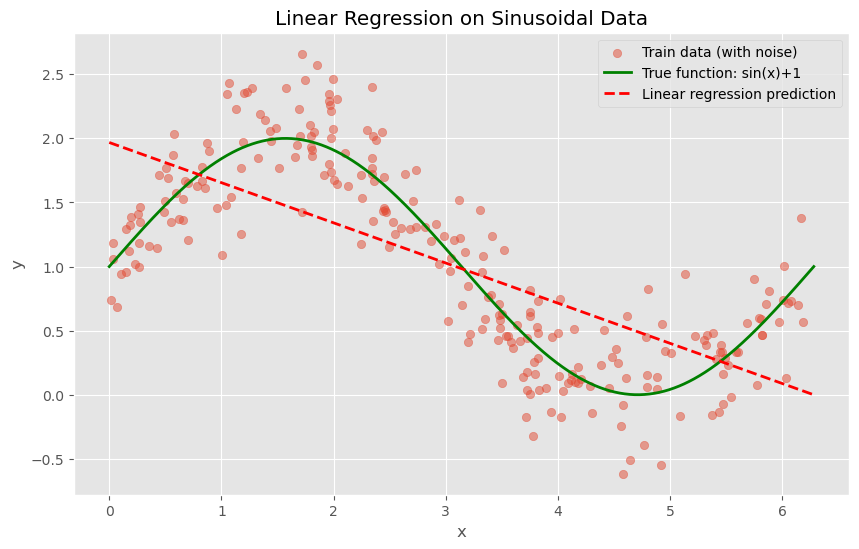

In [35]:
### попробуйте реализовать настройку w и b с помощью рассмотренного выше метода наименьших квадратов.
### Найдите значения метрик MSE и MAE

X, X_train, y_train, X_test, y_test = generate_data(100)

X_wave = data['x_train'].reshape(-1, 1)
y_wave = data['y_train']

X_wave_with_bias = np.hstack([np.ones((len(X_wave), 1)), X_wave])

w_wave = np.linalg.inv(X_wave_with_bias.T @ X_wave_with_bias) @ X_wave_with_bias.T @ y_wave

y_wave_pred = X_wave_with_bias @ w_wave

mse_wave = np.mean((y_wave - y_wave_pred) ** 2)
mae_wave = np.mean(np.abs(y_wave - y_wave_pred))

X_test_wave = data['support'].reshape(-1, 1)
X_test_wave_with_bias = np.hstack([np.ones((len(X_test_wave), 1)), X_test_wave])
y_test_wave_true = data['values']
y_test_wave_pred = X_test_wave_with_bias @ w_wave

mse_test_wave = np.mean((y_test_wave_true - y_test_wave_pred) ** 2)
mae_test_wave = np.mean(np.abs(y_test_wave_true - y_test_wave_pred))

print(f"Линейная регрессия на синусоидальных данных:")
print(f"  w0 (bias) = {w_wave[0]:.4f}, w1 = {w_wave[1]:.4f}")
print(f"  Train MSE = {mse_wave:.4f}, MAE = {mae_wave:.4f}")
print(f"  Test MSE = {mse_test_wave:.4f}, MAE = {mae_test_wave:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_wave, y_wave, alpha=0.5, label='Train data (with noise)')
plt.plot(data['support'], data['values'], 'g-', label='True function: sin(x)+1', linewidth=2)
plt.plot(data['support'], y_test_wave_pred, 'r--', label='Linear regression prediction', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression on Sinusoidal Data')
plt.show()

Конечно, такое решение нас вряд ли может устроить. Нужно применить полинимиальную регрессию. Идея здесь такая. Каждый признак в исходную формулу может входить не только в первой степени, но и во второй, в третьей и так далее. То есть для случая, когда у нас только один признак:
$$ \widehat{y} = w_1 x_1 + w_2 x_1^2 + ... + w_k x_1^k + b,$$

## Задание 3.3

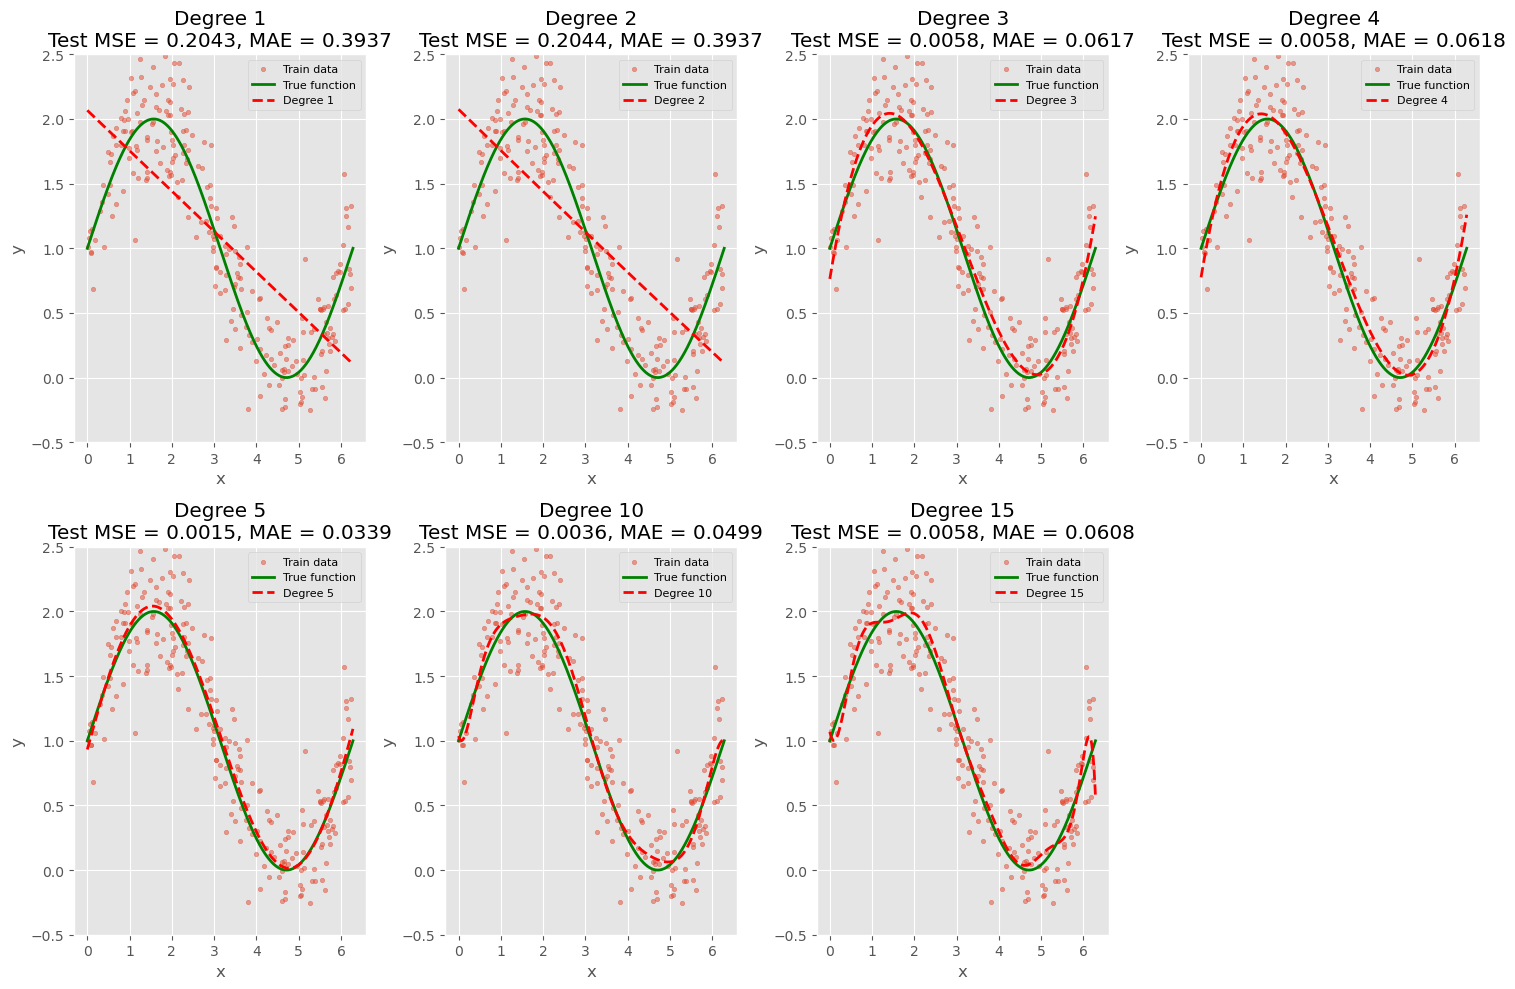


Сравнение метрик для разных степеней:
Degree   Train MSE    Test MSE     Test MAE    
1        0.284150     0.204342     0.393695    
2        0.284140     0.204379     0.393656    
3        0.087788     0.005797     0.061713    
4        0.087772     0.005816     0.061842    
5        0.085307     0.001471     0.033915    
6        0.085269     0.001521     0.034377    
7        0.084795     0.001858     0.037174    
8        0.084699     0.001930     0.037940    
9        0.083405     0.003356     0.048245    
10       0.083305     0.003574     0.049937    
12       0.081451     0.006016     0.060805    
14       0.081398     0.005738     0.060970    
15       0.081414     0.005796     0.060780    

Лучшая степень полинома: 5 (Test MSE = 0.001471)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

### Реализуйте полиномиальную регрессию. Сделайте визуализацию для полиномов разных степеней.
### Полином какой степени подходит больше других? Почему?

data = generate_wave_set(n_support=1000, n_train=250, std=0.3)
X_train = data['x_train'].reshape(-1, 1)
y_train = data['y_train']
X_test = data['support'].reshape(-1, 1)
y_test_true = data['values']

degrees = [1, 2, 3, 4, 5, 10, 15]
plt.figure(figsize=(15, 10))

for i, degree in enumerate(degrees, 1):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test_true, y_test_pred)
    mae_test = mean_absolute_error(y_test_true, y_test_pred)
    
    plt.subplot(2, 4, i)
    plt.scatter(X_train, y_train, alpha=0.5, s=10, label='Train data')
    plt.plot(X_test, y_test_true, 'g-', label='True function', linewidth=2)
    plt.plot(X_test, y_test_pred, 'r--', label=f'Degree {degree}', linewidth=2)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Degree {degree}\nTest MSE = {mse_test:.4f}, MAE = {mae_test:.4f}')
    plt.legend(fontsize=8)
    plt.ylim(-0.5, 2.5)

plt.tight_layout()
plt.show()

# Детальный анализ для выбора лучшей степени
print("\nСравнение метрик для разных степеней:")
print(f"{'Degree':<8} {'Train MSE':<12} {'Test MSE':<12} {'Test MAE':<12}")

best_degree = 1
best_mse = float('inf')

for degree in range(1, 16):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test_true, y_test_pred)
    mae_test = mean_absolute_error(y_test_true, y_test_pred)
    
    if mse_test < best_mse:
        best_mse = mse_test
        best_degree = degree
    
    if degree <= 10 or degree in [12, 14, 15]:
        print(f"{degree:<8} {mse_train:<12.6f} {mse_test:<12.6f} {mae_test:<12.6f}")

print(f"\nЛучшая степень полинома: {best_degree} (Test MSE = {best_mse:.6f})")

Наилучшие результаты показал полином 5 степени. Полином низкой степени недостаточно гибок и не описывает синусоидальную зависимость, а полином высокой степени начинает переобучаться на шум обучающей выборки.

# Реальный датасет

Возьмём реальный набор данных Boston из sklearn.datasets. Этот датасет описывает средние цены на недвижимость в районах Бостона в тысячах долларов.

Примеры признаков объектов недвижимости: количество преступлений на душу населения, процент старых домов в районе, количество учеников на одного учителя и т.д. Обратите внимание на то, что данные уже оцифрованы там, где изначально признаки были качественными.

Загрузим датасет, выведем информацию

In [37]:
import os

df = pd.read_csv('housing.csv')

In [ ]:
from sklearn.model_selection import train_test_split

# Загрузка данных из локального файла
df = pd.read_csv('housing.csv')

# Посмотрим названия столбцов
print("Названия столбцов в файле:")
print(df.columns.tolist())
print("\n")

# Посмотрим первые строки
print("Первые 5 строк данных:")
print(df.head())

Названия столбцов в файле:
[' 0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00']


Первые 5 строк данных:
   0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00
0   0.02731   0.00   7.070  0  0.4690  6.4210  78...                                              
1   0.02729   0.00   7.070  0  0.4690  7.1850  61...                                              
2   0.03237   0.00   2.180  0  0.4580  6.9980  45...                                              
3   0.06905   0.00   2.180  0  0.4580  7.1470  54...                                              
4   0.02985   0.00   2.180  0  0.4580  6.4300  58...                                              


Возьмите датасет отсюда: https://www.kaggle.com/datasets/vikrishnan/boston-house-prices/

## Задание 3.4

In [ ]:
### оставьте в наборе данных только 7 наиболее значимых признаков
### настройте параметры линейной регрессии и сравните метрики качества (MSE и MAE) для полного датасета и усечённого

# Загрузка данных
df = pd.read_csv('housing.csv', sep='\s+', header=None)

# Назначаем названия столбцов
df.columns = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 
              'tax', 'ptratio', 'b', 'lstat', 'medv']

print("Названия столбцов в файле:")
print(df.columns.tolist())
print("\nПервые 5 строк данных:")
print(df.head())

X = df.drop('medv', axis=1)
y = df['medv']

print(f"\nРазмер X: {X.shape}")
print(f"Признаки: {list(X.columns)}")

correlations = pd.DataFrame({
    'feature': X.columns,
    'correlation': [abs(X[col].corr(y)) for col in X.columns]
}).sort_values('correlation', ascending=False)

print("\nПолная таблица корреляции признаков с ценой (medv):")
print(correlations.to_string(index=False))

top7_features = correlations.head(7)['feature'].tolist()
print(f"\n7 наиболее значимых признаков: {top7_features}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


lr_full = LinearRegression()
lr_full.fit(X_train, y_train)
y_pred_full_train = lr_full.predict(X_train)
y_pred_full_test = lr_full.predict(X_test)


X_train_7 = X_train[top7_features]
X_test_7 = X_test[top7_features]

lr_7 = LinearRegression()
lr_7.fit(X_train_7, y_train)
y_pred_7_train = lr_7.predict(X_train_7)
y_pred_7_test = lr_7.predict(X_test_7)

# Сравнение результатов
print("Сравнение метрик качества:")
print(f"{'Метрика':<20} {'Все признаки (13)':<25} {'Только 7 признаков':<25}")

mse_full_train = mean_squared_error(y_train, y_pred_full_train)
mse_full_test = mean_squared_error(y_test, y_pred_full_test)
mae_full_train = mean_absolute_error(y_train, y_pred_full_train)
mae_full_test = mean_absolute_error(y_test, y_pred_full_test)

mse_7_train = mean_squared_error(y_train, y_pred_7_train)
mse_7_test = mean_squared_error(y_test, y_pred_7_test)
mae_7_train = mean_absolute_error(y_train, y_pred_7_train)
mae_7_test = mean_absolute_error(y_test, y_pred_7_test)

print(f"{'Train MSE':<20} {mse_full_train:<25.4f} {mse_7_train:<25.4f}")
print(f"{'Test MSE':<20} {mse_full_test:<25.4f} {mse_7_test:<25.4f}")
print(f"{'Train MAE':<20} {mae_full_train:<25.4f} {mae_7_train:<25.4f}")
print(f"{'Test MAE':<20} {mae_full_test:<25.4f} {mae_7_test:<25.4f}")

# Вывод коэффициентов для модели на 7 признаках
print("Коэффициенты модели (только 7 признаков):")
for feat, coef in zip(top7_features, lr_7.coef_):
    print(f"  {feat:10} : {coef:10.4f}")
print(f"  {'bias':10} : {lr_7.intercept_:10.4f}")

# Анализ результатов
print("Анализ:")
print(f"Уменьшение числа признаков с 13 до 7:")
print(f"  - Изменение Test MSE: {(mse_full_test - mse_7_test):.4f}")
print(f"  - Изменение Test MAE: {(mae_full_test - mae_7_test):.4f}")

if mse_7_test < mse_full_test:
    print("  ✓ Модель на 7 признаках показывает ЛУЧШИЕ результаты!")
else:
    print("  ✗ Модель на всех признаках показывает ЛУЧШИЕ результаты")

Названия столбцов в файле:
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']

Первые 5 строк данных:
      crim    zn  indus  chas    nox     rm   age     dis  rad    tax  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   ptratio       b  lstat  medv  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Размер X: (506, 13)
Признаки: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']

Полная таблица корреляции признаков с ценой (medv):
feature  correlati